 # <font color="#ffd700"> Dog and Cat Classification using CNN Projesi: </font>

&nbsp;&nbsp;&nbsp; Dünyaca durgun olan yılları içeren Pandemiden sonra evde evcil hayvan beslemek yaygınlaşmıştır. Bu projemizde ise popüler evcil hayvan türü arasında ayrım yapabilen derin öğrenme yöntemi ile oluşturulmuş bir model eğitilecektir. Veri setimiz görüntü sınıflandırma görevlerinde kullanılmak üzere tasarlanmış, kedi ve köpekleri içeren bir resim koleksiyonudur ve projemizde amacımız verilen bir resmin model tarafından kedi veya köpek olduğunu tahmin eden bir model oluşturmaktır. Datamız 2 veri setinden (Cat and Dog) yani klasörden oluşuyor. Bu sebeple bu bir 'Classification' projesidir. Modelimiz üzerinde dolaylı amacımız accuracy_score'u yani modelin tahmin oranını %80 üzerinde tutmak olacaktır. 

In [2]:
# Merhaba,
# Bu ödevde verilecek cevaplarıma kullanmak adına karar kıldığım Font '#ffd700' dur.

#### **Veri Setimiz:** <br>
**Cat:** Kedi resimlerini içeren klasör <br>
**Dog:** Köpek resimlerini içeren klasör <br>

***Hedef Sütunumuz:*** 'label_encoded' (1 ifadesi cat yani kedi iken, 0 ifadesi dog yani köpek olan resimleri temsil eder).  

<img src="https://www.hauseofistanbul.com/images/icerik/buyuk/kedi-ve-kopekler-arasinda-ki-farklar-nelerdir-.webp">

In [3]:
import cv2
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

from keras.models import Sequential
from keras.layers import Conv2D,Dense,Flatten,Input,MaxPooling2D,Dropout,BatchNormalization,Reshape

import os
import matplotlib.pyplot as plt

## <font color="#ffd700"> Feature Engineering: </font>

&nbsp;&nbsp;&nbsp;Öncelikle datamız resimlerden oluştuğu için klasörleri projemize ekleyip iki etiket altında ayırıyoruz klasör başlıkları ile.

In [4]:
labels=['Cat','Dog']
img_path='Train/' 

In [5]:
img_list=[]
label_list=[]
for label in labels:
    for img_file in os.listdir(img_path+label):
        img_list.append(img_path+label+"/"+img_file)
        label_list.append(label)

&nbsp;&nbsp;&nbsp;İki farklı klasörü 'label' altında topladıktan sonra, resimlerin yollarını belirten bilgiyi de 'img' altına toplayarak her iki bilgiyi DataFrame haline getirerek onları sütunlaştırıyoruz işleyebilmek adına. 

In [6]:
df=pd.DataFrame({'img':img_list, 'label':label_list})

In [7]:
df

,img,label
0,Train/Cat/cat.0.jpg,Cat
1,Train/Cat/cat.1.jpg,Cat
2,Train/Cat/cat.10.jpg,Cat
3,Train/Cat/cat.100.jpg,Cat
4,Train/Cat/cat.1000.jpg,Cat
...,...,...
23645,Train/Dog/dog.9995.jpg,Dog
23646,Train/Dog/dog.9996.jpg,Dog
23647,Train/Dog/dog.9997.jpg,Dog
23648,Train/Dog/dog.9998.jpg,Dog


&nbsp;&nbsp;&nbsp;Daha sonra 'label' sütunu altında yer alan iki farklı klasörü temsil eden değerleri bool değerler haline getirip onlardan 'label_encoded' adlı sütunu yaratıyoruz. 

In [8]:
d=({'Cat':1, 'Dog':0})
df['label_encoded']=df['label'].map(d)

In [9]:
df

,img,label,label_encoded
0,Train/Cat/cat.0.jpg,Cat,1
1,Train/Cat/cat.1.jpg,Cat,1
2,Train/Cat/cat.10.jpg,Cat,1
3,Train/Cat/cat.100.jpg,Cat,1
4,Train/Cat/cat.1000.jpg,Cat,1
...,...,...,...
23645,Train/Dog/dog.9995.jpg,Dog,0
23646,Train/Dog/dog.9996.jpg,Dog,0
23647,Train/Dog/dog.9997.jpg,Dog,0
23648,Train/Dog/dog.9998.jpg,Dog,0


&nbsp;&nbsp;&nbsp;Şimdi elimizde olan resimleri işleyebilmek adına boyutlandırıp, normalize ediyoruz.

In [10]:
x = []  # boş liste
for img in df['img']:
    img = cv2.imread(str(img))  # Resmi oku
    if img is not None:  # Resmin başarıyla okunduğundan emin ol
        img = cv2.resize(img, (170, 170))  # yeniden boyutlandır
        img = img.astype(np.float32) / 255.0  # normalize et
        x.append(img)  # resmi listeye ekle
    else:
        print(f"Resim okunamadı: {img}")  # Hata mesajı ver

&nbsp;&nbsp;&nbsp;Bu noktada x içerisinde yer alan resimlerin birer diziye çevirmeliyiz.

In [11]:
x=np.array(x) 

&nbsp;&nbsp;&nbsp;Ve hedef sütunumuzda kedi olanlara 1, köpek olanlara 0 değeri verdiğimiz 'label_encoded' sütunu oluyor.

In [13]:
y=df[['label_encoded']]

## <font color="#ffd700"> Model and Testing: </font>

&nbsp;&nbsp;&nbsp;Modelimizin hedefi ve işlenecek datası belli olduğuna göre onu eğitim ve test kısımlarına ayırıp test edip modelleyelim.

In [14]:
x_train,x_test,y_train,y_test=train_test_split(x,y, random_state=42, test_size=0.20)

In [15]:
y_train=np.array(y_train, dtype=np.int32)
y_test=np.array(y_test, dtype=np.int32)

&nbsp;&nbsp;&nbsp;Modelimizi Deep Learning ile eğitiyoruz.

In [16]:
model=Sequential()
model.add(Input(shape=(170, 170, 3)))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2))) # maxpooling aşırı ezberlemeyi engelliyor
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))  # Added activation function
model.add(Dense(1, activation='sigmoid'))  # classification old. icin sigmoid

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']) # 2 secenek old. zaman binary olani yaziyoruz

In [17]:
history=model.fit(x_train,y_train,validation_data=(x_test,y_test), epochs=20,verbose=1)

Epoch 1/20
592/592 ━━━━━━━━━━━━━━━━━━━━ 166s 276ms/step - accuracy: 0.6156 - loss: 0.6671 - val_accuracy: 0.7220 - val_loss: 0.5532
Epoch 2/20
592/592 ━━━━━━━━━━━━━━━━━━━━ 147s 248ms/step - accuracy: 0.7541 - loss: 0.5029 - val_accuracy: 0.7304 - val_loss: 0.5418
Epoch 3/20
592/592 ━━━━━━━━━━━━━━━━━━━━ 148s 251ms/step - accuracy: 0.8294 - loss: 0.3792 - val_accuracy: 0.7712 - val_loss: 0.4952
Epoch 4/20
592/592 ━━━━━━━━━━━━━━━━━━━━ 145s 244ms/step - accuracy: 0.9077 - loss: 0.2259 - val_accuracy: 0.7708 - val_loss: 0.5759
Epoch 5/20
592/592 ━━━━━━━━━━━━━━━━━━━━ 146s 246ms/step - accuracy: 0.9687 - loss: 0.0904 - val_accuracy: 0.7685 - val_loss: 0.8078
Epoch 6/20
592/592 ━━━━━━━━━━━━━━━━━━━━ 145s 246ms/step - accuracy: 0.9888 - loss: 0.0373 - val_accuracy: 0.7641 - val_loss: 1.0060
Epoch 7/20
592/592 ━━━━━━━━━━━━━━━━━━━━ 145s 245ms/step - accuracy: 0.9937 - loss: 0.0240 - val_accuracy: 0.7679 - val_loss: 1.2570
Epoch 8/20
592/592 ━━━━━━━━━━━━━━━━━━━━ 146s 246ms/step - accuracy: 0.9946 -

In [28]:
#Burada modeli kaydettim fakat yanlış isimle kaydettiğim için dosya üzerinden ismini yeniden adlandırıp incelemek için tekrar yükledim Jupiter'e

&nbsp;&nbsp;&nbsp;Bu noktada çalıştırıp kaydettiğim modeli tekrar yüklüyorum özetini inceleyebilmek adına.

In [23]:
from keras.models import load_model

In [24]:
model = load_model('cat_dog_model.h5')

In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 168, 168, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 84, 84, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 82, 82, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 41, 41, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 107584)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      13,770,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,790,403 (52.61 MB)

 Trainable params: 13,790,401 (52.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [26]:
history.history['accuracy']

[0.6155919432640076,
 0.7541226148605347,
 0.8294397592544556,
 0.907716691493988,
 0.9686574935913086,
 0.9887949228286743,
 0.9936575293540955,
 0.9946088790893555,
 0.9948731660842896,
 0.995665967464447,
 0.9952960014343262,
 0.997198760509491,
 0.9933932423591614,
 0.9949259757995605,
 0.9988372325897217,
 0.9974629878997803,
 0.9959830641746521,
 0.9987843632698059,
 0.9982029795646667,
 0.9980443716049194]

&nbsp;&nbsp;&nbsp;Ve yukarıda olduğu gibi modelimizin doğruluk oranının geçmişine bakarsak, tahmin oranımız %99'ları buluyor gibi model datamızı öğrendikçe.

&nbsp;&nbsp;&nbsp;Şimdi modelimizin datayı iyi öğrendiğini ve iyi tahmin yapabildiğini zaten son gelen accuracy oranlarından anlıyoruz ama bunu yine görselleştirelim. 

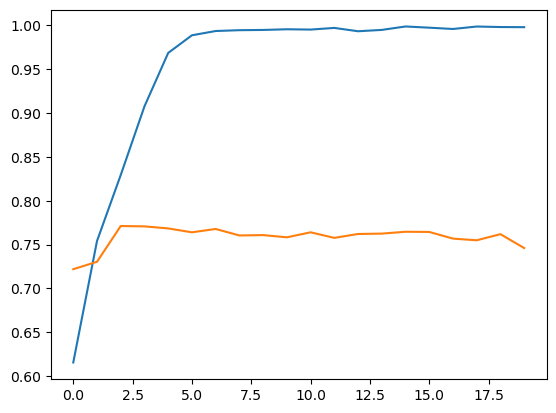

In [27]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy']);

**Conclusion:** &nbsp;&nbsp;Sonuç olarak kendi modelimizi kaydettiğimiz 'cat_dog__model.h5' modeline bakılırsa 'accuracy: 0.9980' ları görüyor. Bu demektir ki modelimiz verilen resmin kedi mi köpek mi olduğunun tahminini yaptığında doğruluk oranı çok yüksek ve eğitim datası modelimiz tarafından gayet iyi anlaşılmış ve eğitilmiştir. <br><br>
&nbsp;&nbsp;&nbsp;Peki bu çalışma ne işimize yaradı, sorusuyla siz de benim gibi başbaşa iseniz şunu belirtebilirim. Bu çalışmanın gerçek hayata yansıması biraz hayal ettiğinizde ortaya dökülebilir. Örneğin bu çalışma gibi üretilen bir model eğer öğrendiği resimlerden bir hayvanın kedi mi köpek mi olduğunu bir tek öğrenme ile tanıyabilir hale geliyorsa, bu şu demektir; buna benzer öğrenilmiş modellerde kamera sistemleri bir noktada insanlar arasında kargaşa olup olmayacağını, çatışma çıkıp çıkmayacağını belirleyebilir ve otomatik polis çağırabilir hale gelebilir. Böylece toplum güvenliği arttırılabilir. Veyahut bir başka örnek vermek gerekirse sınırdan ya da sınır denizlerimizden gelen gemilerin taşıdıkları bayraklara göre kamera sistemleri ve yapay zeka, gelen geminin ülkesini öğrendiği model ile tanımlayabilir ve buna göre önceden uyarı verebilir gibi örnekler üretebiliriz bu modellerin kullanım alanları olarak. 

Ve kapanış..